# 02 — Análisis Exploratorio del Dataset

Comparamos el dataset original vs el aumentado en:
- Distribución de clases
- Longitud de textos
- Vocabulario y frecuencia de términos
- Calidad de las aumentaciones (similitud semántica)

**Prerequisito:** haber ejecutado `01_data_augmentation.ipynb`

In [8]:
import json
import sys
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

ROOT = Path().resolve().parents[3]
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
print('OK')

OK


In [9]:
CSV_PATH  = ROOT / 'src/classifier/classifier_dataset_fusionado/datasets/eu_ai_act_flagged_es_limpio.csv'
JSONL_PATH = ROOT / 'src/classifier/bert_pipeline/data/dataset_augmented.jsonl'

df_orig = pd.read_csv(CSV_PATH)[['descripcion', 'etiqueta_normalizada']].dropna()
df_orig['source'] = 'original'

if JSONL_PATH.exists():
    records = [json.loads(l) for l in JSONL_PATH.read_text(encoding='utf-8').splitlines() if l.strip()]
    df_aug = pd.DataFrame(records).rename(columns={'etiqueta': 'etiqueta_normalizada'})
    print(f'Dataset original : {len(df_orig)} ejemplos')
    print(f'Dataset aumentado: {len(df_aug)} ejemplos (x{len(df_aug)/len(df_orig):.1f})')
else:
    df_aug = None
    print('⚠️  JSONL no encontrado — ejecuta primero 01_data_augmentation.ipynb')
    print(f'Dataset original : {len(df_orig)} ejemplos')

Dataset original : 832 ejemplos
Dataset aumentado: 3998 ejemplos (x4.8)


## 1. Distribución de clases

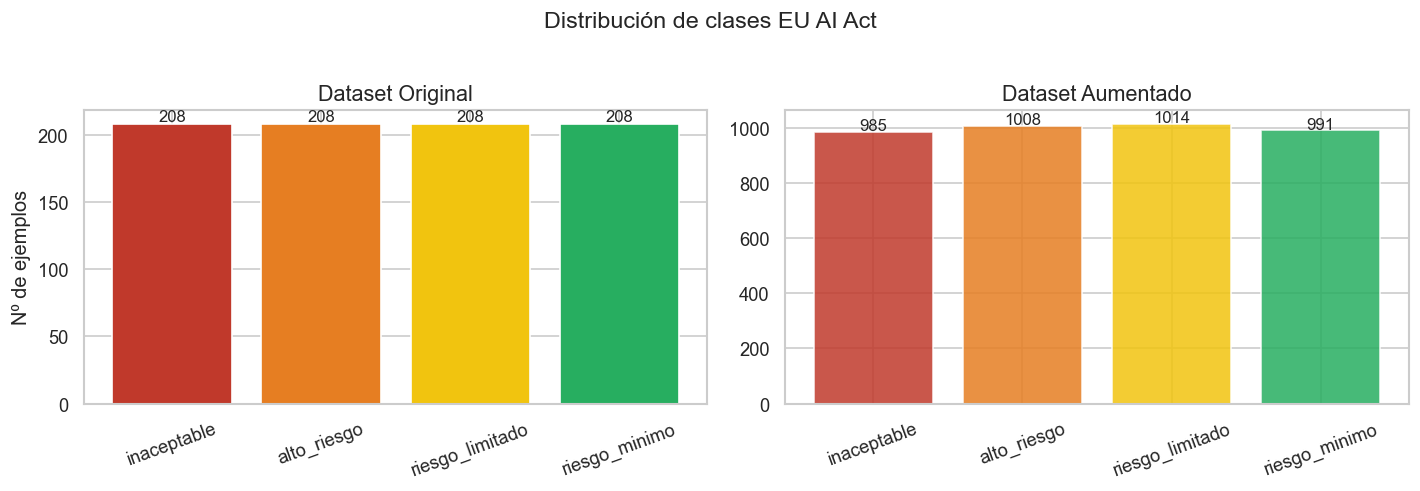

In [10]:
LABEL_ORDER = ['inaceptable', 'alto_riesgo', 'riesgo_limitado', 'riesgo_minimo']
COLORS = ['#c0392b', '#e67e22', '#f1c40f', '#27ae60']

fig, axes = plt.subplots(1, 2 if df_aug is not None else 1, figsize=(12, 4))
if df_aug is None:
    axes = [axes]

counts_orig = df_orig['etiqueta_normalizada'].value_counts().reindex(LABEL_ORDER, fill_value=0)
axes[0].bar(LABEL_ORDER, counts_orig.values, color=COLORS)
axes[0].set_title('Dataset Original', fontsize=13)
axes[0].set_ylabel('Nº de ejemplos')
axes[0].tick_params(axis='x', rotation=20)
for i, v in enumerate(counts_orig.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontsize=10)

if df_aug is not None:
    counts_aug = df_aug['etiqueta_normalizada'].value_counts().reindex(LABEL_ORDER, fill_value=0)
    axes[1].bar(LABEL_ORDER, counts_aug.values, color=COLORS, alpha=0.85)
    axes[1].set_title('Dataset Aumentado', fontsize=13)
    axes[1].tick_params(axis='x', rotation=20)
    for i, v in enumerate(counts_aug.values):
        axes[1].text(i, v + 5, str(v), ha='center', fontsize=10)

plt.suptitle('Distribución de clases EU AI Act', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(ROOT / 'src/classifier/bert_pipeline/data/dist_clases.png', bbox_inches='tight')
plt.show()

## 2. Distribución de longitud de textos

=== Dataset Original ===
                       count   mean    std    min    25%    50%    75%    max
etiqueta_normalizada                                                        
alto_riesgo           208.0  193.5   57.7  128.0  146.0  180.0  206.0  371.0
inaceptable           208.0  261.5   67.6  151.0  193.8  266.0  316.2  413.0
riesgo_limitado       208.0  174.6   51.9  125.0  143.8  150.0  196.0  409.0
riesgo_minimo         208.0  251.3  104.9   41.0  156.0  206.5  328.0  559.0


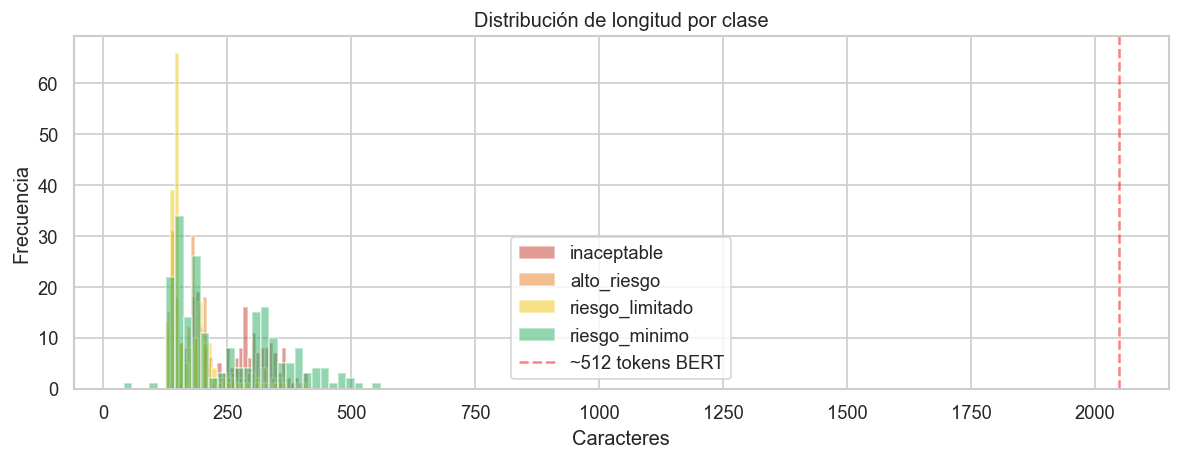


Ejemplos que posiblemente superen 512 tokens: 0.0%


In [15]:
df_orig['longitud'] = df_orig['descripcion'].str.len()
print('=== Dataset Original ===\n', df_orig.groupby('etiqueta_normalizada')['longitud'].describe().round(1).to_string())

fig, ax = plt.subplots(figsize=(10, 4))
for label, color in zip(LABEL_ORDER, COLORS):
    subset = df_orig[df_orig['etiqueta_normalizada'] == label]['longitud']
    ax.hist(subset, bins=30, alpha=0.5, label=label, color=color)
ax.set_xlabel('Caracteres')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución de longitud por clase')
ax.axvline(512*4, color='red', linestyle='--', alpha=0.5, label='~512 tokens BERT')
ax.legend()
plt.tight_layout()
plt.show()

pct_largo = (df_orig['longitud'] > 512*4).mean() * 100
print(f'\nEjemplos que posiblemente superen 512 tokens: {pct_largo:.1f}%')

## 3. Términos más frecuentes por clase

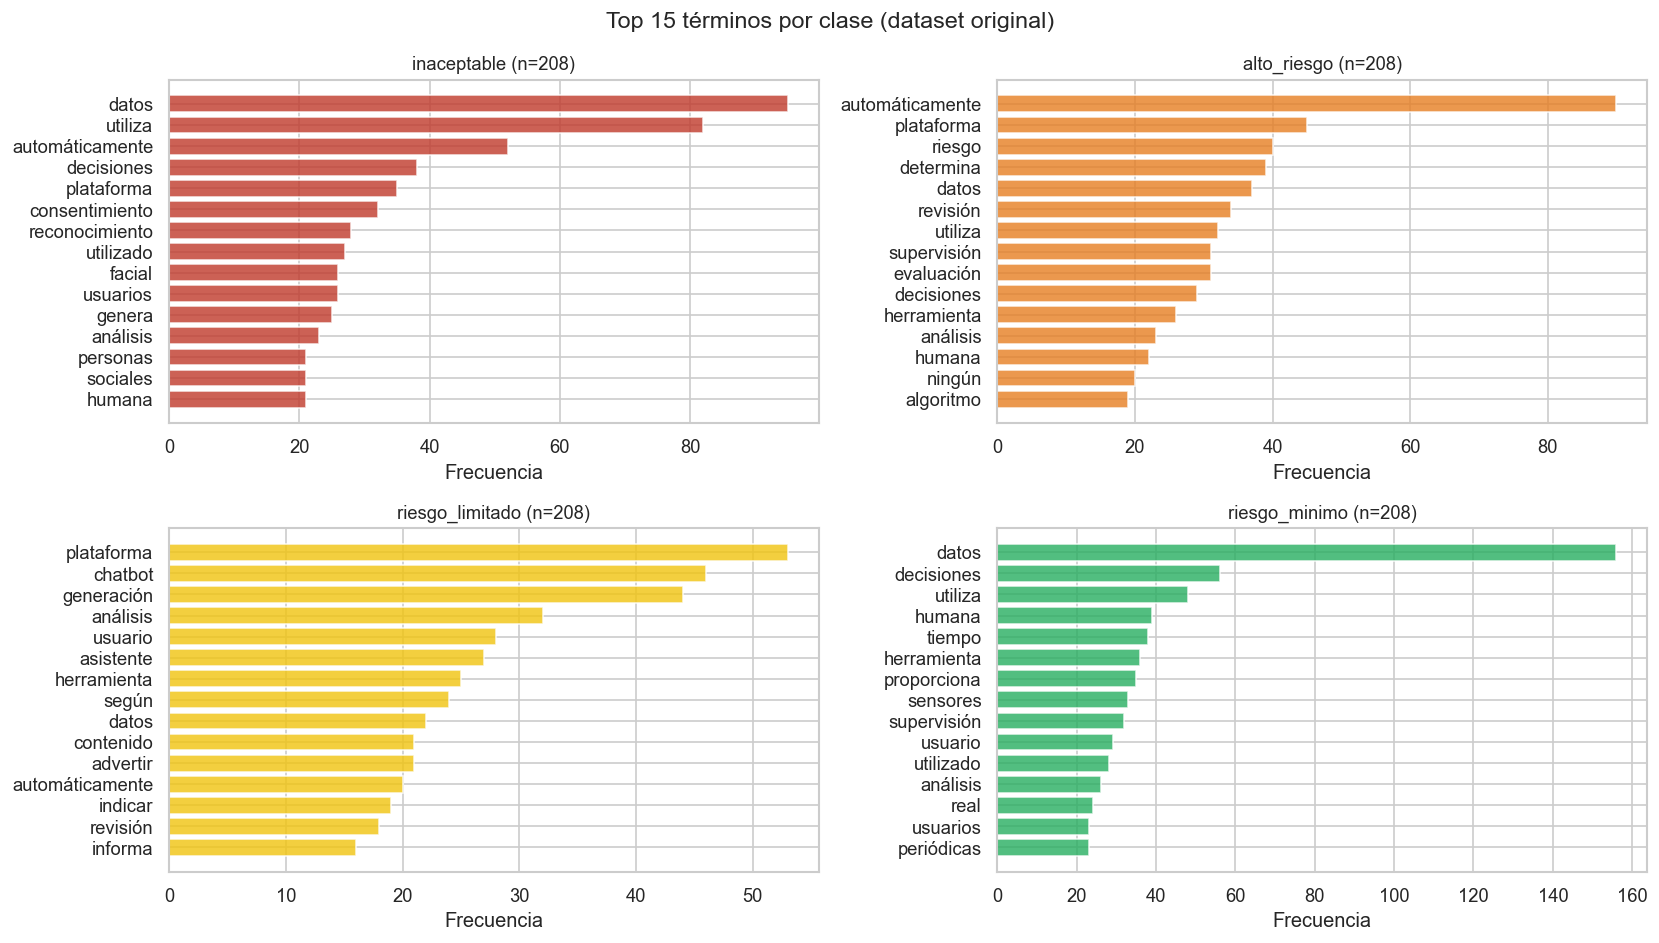

In [16]:
import re

STOPWORDS = {
    'de','la','el','en','un','una','los','las','para','con','que','del',
    'por','se','su','al','es','lo','las','una','este','esta','como','son',
    'más','sin','sobre','entre','sistema','inteligencia','artificial','ia',
}

def top_words(texts, n=15):
    tokens = re.findall(r'\b[a-záéíóúüñ]{4,}\b', ' '.join(texts).lower())
    return Counter(t for t in tokens if t not in STOPWORDS).most_common(n)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, (label, color) in zip(axes.flatten(), zip(LABEL_ORDER, COLORS)):
    texts = df_orig[df_orig['etiqueta_normalizada'] == label]['descripcion'].tolist()
    words, counts = zip(*top_words(texts))
    ax.barh(list(reversed(words)), list(reversed(counts)), color=color, alpha=0.8)
    ax.set_title(f'{label} (n={len(texts)})', fontsize=11)
    ax.set_xlabel('Frecuencia')

plt.suptitle('Top 15 términos por clase (dataset original)', fontsize=14)
plt.tight_layout()
plt.savefig(ROOT / 'src/classifier/bert_pipeline/data/top_terms.png', bbox_inches='tight')
plt.show()

## 4. Calidad de las aumentaciones

Comparamos longitud media de originales vs aumentaciones para detectar si el LLM está generando textos demasiado cortos o largos.

Longitud media por fuente:
                   mean  min  max
source                           
paraphrase_1      158.7   21  567
paraphrase_3      161.0   21  563
paraphrase_2      161.9   21  584
back_translation  209.8  104  531
original          220.2   41  559


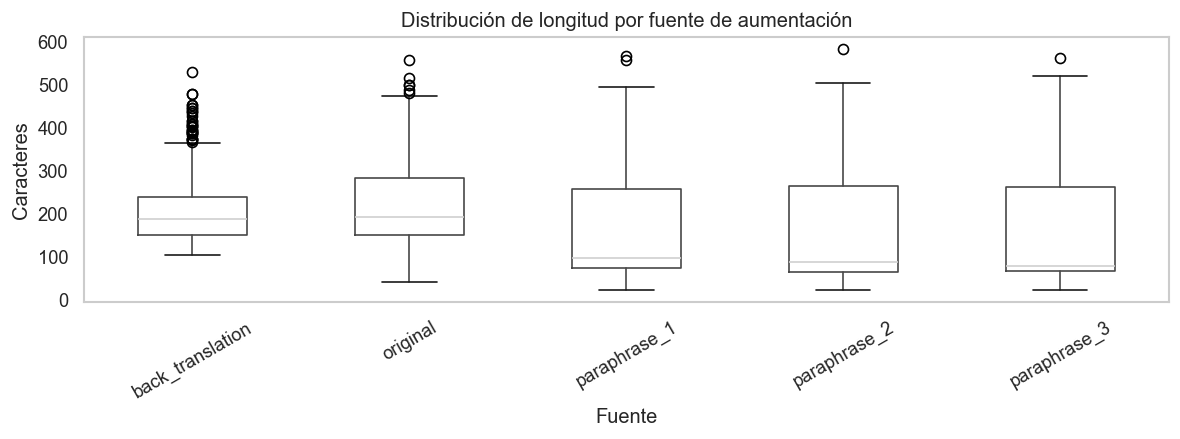


Distribución de clases en dataset aumentado:
etiqueta_normalizada
riesgo_limitado    1014
alto_riesgo        1008
riesgo_minimo       991
inaceptable         985


In [17]:
if df_aug is not None:
    df_aug['longitud'] = df_aug['descripcion'].str.len()

    print('Longitud media por fuente:')
    print(df_aug.groupby('source')['longitud'].agg(['mean','min','max']).round(1).sort_values('mean').to_string())

    fig, ax = plt.subplots(figsize=(10, 4))
    df_aug.boxplot(column='longitud', by='source', ax=ax, grid=False)
    plt.suptitle('')
    ax.set_title('Distribución de longitud por fuente de aumentación')
    ax.set_xlabel('Fuente')
    ax.set_ylabel('Caracteres')
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

    print('\nDistribución de clases en dataset aumentado:')
    print(df_aug['etiqueta_normalizada'].value_counts().to_string())
else:
    print('Skipped — no hay dataset aumentado.')

## 5. Resumen ejecutivo

In [18]:
print('=== RESUMEN EDA ===')
print(f'Dataset original    : {len(df_orig)} ejemplos, {df_orig["etiqueta_normalizada"].nunique()} clases')
print(f'Longitud media      : {df_orig["longitud"].mean():.0f} chars')
print(f'Clase minoritaria   : {df_orig["etiqueta_normalizada"].value_counts().idxmin()} ({df_orig["etiqueta_normalizada"].value_counts().min()} ejemplos)')
print(f'Clase mayoritaria   : {df_orig["etiqueta_normalizada"].value_counts().idxmax()} ({df_orig["etiqueta_normalizada"].value_counts().max()} ejemplos)')
if df_aug is not None:
    print(f'Dataset aumentado   : {len(df_aug)} ejemplos (x{len(df_aug)/len(df_orig):.1f})')
print('\nConclusión: class_weight="balanced" recomendado para BERT (clases desbalanceadas)')

=== RESUMEN EDA ===
Dataset original    : 832 ejemplos, 4 clases
Longitud media      : 220 chars
Clase minoritaria   : riesgo_minimo (208 ejemplos)
Clase mayoritaria   : riesgo_minimo (208 ejemplos)
Dataset aumentado   : 3998 ejemplos (x4.8)

Conclusión: class_weight="balanced" recomendado para BERT (clases desbalanceadas)
